## `merged_results.ipynb`

-----------------------

This notebook collates the results and plots them. Most methods are accessible in `inference.py`

In [1]:
import numpy as np 
import fitsio as fio
import pandas as pd 
import importlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import src.statistics.sgp as sgp

from scipy.interpolate import interp1d
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from pathlib import Path
from scipy.integrate import simpson
from scipy.interpolate import RegularGridInterpolator
from scipy.optimize import curve_fit

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel

import src.statistics.inference as inference
import src.statistics.combination as comb
import src.statistics.cosmotools as ct
import src.statistics.corrfiles as cf
import src.statistics.calibration as cal

# Methods:
----------

We use the [Euclid](https://arxiv.org/pdf/2208.10503) approach (derived from Schmidt+2013):

We use : 
$n_{p, m}(z_{j, t})\propto \frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r)}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$ the scale averaged two point correlation function between samples x, y.

- $z_{j, t}$ : center of the fine bin j for the t tracer (ELG, LRG ...)
- $m$ : id of the tomographic bin
- $s$ : spectroscopic sample
- $p$ : photometric sample

Cosmology used (for distances in $h^{-1}Mpc$) :
- $\Omega_c = 0.258868$ (cold dark matter density fraction)
- $\Omega_b = 0.048252$ (baryon density fraction)
- $\Omega_m=\Omega_c+\Omega_b$ (matter density fraction)
- $h = 0.6777$
- $H_0 = h * 100$
- $\sigma_8 = 0.8$
- $n_s = 0.95$

DES Y3 Approach :

-----------------

$n_{p, m}(z_{j, t})\propto\frac{\bar{\omega}_{\rm{sp},\:m}(r,\:z_{j, t})}{\sqrt{\bar{\omega}_{\rm{ss}}(r,\:z_{j, t})\bar{\omega}_{\rm{pp},\:m}(r, z_{j, t})\sigma_j}}$ with $\bar{\omega}_{xy}(r, z_j)=\int_{r_{min}}^{r_{max}}W(r)\omega_{xy}(r, z_j)$

This approach does not really work well due to the very high variations in $\sigma_j$ caused by the photometric method itself (redshift spikes)


In [2]:
ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/')
bins_hsc = np.arange(0.3, 1.8, 0.3)
markers = ['x', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

In [3]:
stem = 'v10'
path_dictionary = {
    'HSC' : ROOT / 'v12_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
assert all([p.exists() for p in path_dictionary.values()])

In [4]:
outdir = ROOT / f'merged_{stem}'

In [6]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
inference.merge_estimators(
    path_dictionary=path_dictionary, 
    outdir=outdir, 
    verbose=True,
    tomo_interest=[1, 2, 3, 4]
    )

Processing redshift bin 0 (Completion : 1.79%)
Processing redshift bin 5 (Completion : 10.71%)
Processing redshift bin 10 (Completion : 19.64%)
Processing redshift bin 15 (Completion : 28.57%)
Processing redshift bin 20 (Completion : 37.50%)
Processing redshift bin 25 (Completion : 46.43%)
Processing redshift bin 30 (Completion : 55.36%)
Processing redshift bin 35 (Completion : 64.29%)
Processing redshift bin 40 (Completion : 73.21%)
Processing redshift bin 45 (Completion : 82.14%)
Processing redshift bin 50 (Completion : 91.07%)
Processing redshift bin 55 (Completion : 100.00%)
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_v10/MergedxHSC/MergedxHSC_b1x1_b2x1.npy
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/merged_v10/MergedxHSC/MergedxHSC_b1x1_b2x2.npy
Saved cross-correlation estimator to /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/

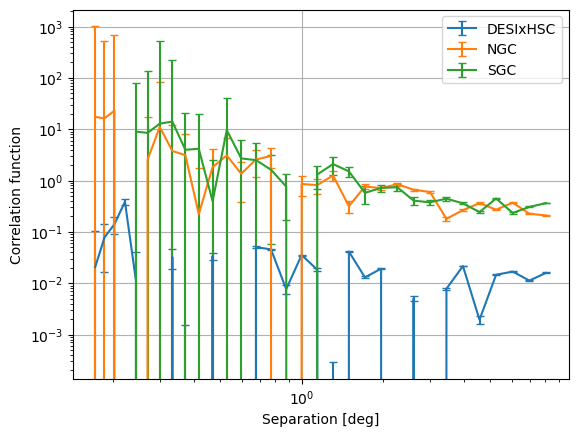

In [5]:
from pycorr import TwoPointEstimator
tgt = 'QSO'  # Target tracer
b = 4
b2 = 4
tpcf1 = TwoPointEstimator.load(f'/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/{stem}/autos_NGC/{tgt}x{tgt}/{tgt}x{tgt}_b1x{b}_b2x{b}_moc1.npy')
tpcf2 = TwoPointEstimator.load(f'/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/{stem}/autos_SGC/{tgt}x{tgt}/{tgt}x{tgt}_b1x{b}_b2x{b}_moc3.npy')
crosspcf1 = TwoPointEstimator.load(f'/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/src/statistics/outputs/{stem}/cross/{tgt}xHSC/{tgt}xHSC_b1x{b}_b2x{b2}_moc1.npy')
plt.errorbar(ct.arcsec2hMpc(0.5*(crosspcf1.edges[0][1:] + crosspcf1.edges[0][:1])*3600, z=2), crosspcf1.corr, np.sqrt(np.diag(crosspcf1.cov())**2), label='DESIxHSC', capsize=3)
plt.errorbar(ct.arcsec2hMpc(0.5*(tpcf1.edges[0][1:] + tpcf1.edges[0][:1])*3600, z=2), tpcf1.corr, np.sqrt(np.diag(tpcf1.cov())**2), label='NGC', capsize=3)
plt.errorbar(ct.arcsec2hMpc(0.5*(tpcf2.edges[0][1:] + tpcf2.edges[0][:1])*3600, z=2), tpcf2.corr, np.sqrt(np.diag(tpcf2.cov())**2), label='SGC', capsize=3)
plt.xscale('log')
plt.xlabel('Separation [deg]')
plt.ylabel('Correlation function')
plt.legend()
plt.yscale('log')
plt.grid()

In [6]:
path_dictionary.update({
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
})

In [7]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(ct)
importlib.reload(cf)
meas = inference.full_npz_tomo(
    path_dictionary=path_dictionary,
    do_bias_correction=False,
    scale_cuts=[1, 5],
    tracer='Merged',
    tomo_bin=2,
    verbose=True,
    rebin=1
)

Using fine redshift : [0.   0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65
 0.7  0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35
 1.4  1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.   2.05
 2.1  2.15 2.2  2.25 2.3  2.35 2.4  2.45 2.5  2.55 2.6  2.65 2.7  2.75
 2.8 ]
Using merged method for tracer Merged and tomo bin 2.


56 56 56
Integrated p(z) = 0.571
Expected p(z) = 0.557


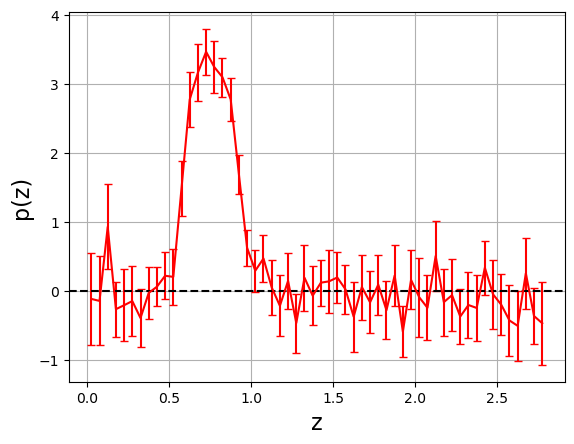

In [8]:
zbins = inference._get_fine_redshift_bins(fr=cf.CorrFileReader(path_dictionary["DESI_NGC"]))
zval = (zbins[1:] + zbins[:-1])/2  # we only want the middle values
print(len(zval), len(meas[0]), len(meas[1]))
plt.errorbar(zval, meas[0]/simpson(meas[0], zval), meas[1]/simpson(meas[0], zval), capsize=3, color='red')
plt.axhline(0, color='k', linestyle='--')
plt.grid()
plt.xlabel('z', fontsize=16)
plt.ylabel('p(z)', fontsize=16)

print(f'Integrated p(z) = {simpson(meas[0], zval):.3f}')
print(f'Expected p(z) = {simpson(np.multiply(zval, meas[0]/simpson(meas[0], zval)), zval):.3f}')

In [49]:
importlib.reload(ct)
mask = (zval < 2) & (zval > 0.7)
mask = np.ones_like(zval, dtype=bool)  # use all z values

zcen = .8
sigma = 0.16
b = meas[0][mask]
normal_dist = np.exp(-0.5 * ((zval - zcen) / sigma) ** 2)
dz = np.diff(zval).mean()

normal_dist /= np.sum(normal_dist * dz)
b = normal_dist

#b = meas[0][mask] / simpson(meas[0][mask], zval[mask])
A = [ct.mag_coeffs(zind, zval[mask], contribution=["Du", "uD", "DD"]) for zind in range(len(zval[mask]))]

In [50]:
npz = np.linalg.solve(A, b)

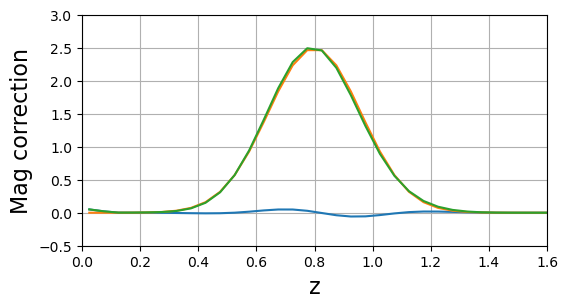

In [57]:
plt.figure(figsize=(6, 3))
plt.plot(zval[mask], npz, label='Uncorrected')
plt.plot(zval[mask], b, label='Mag correction')
plt.plot(zval[mask], b+npz, label='Corrected for magnification')
#plt.errorbar(zval, meas[0], meas[1], label='p(z)')
plt.xlabel('z', fontsize=16)
plt.ylabel('Mag correction', fontsize=16)
plt.ylim(-.5, 3)
plt.xlim(0, 1.6)
plt.grid()

Using fine redshift : [0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08
 1.12 1.16 1.2  1.24 1.28 1.32 1.36 1.4  1.44 1.48 1.52 1.56 1.6  1.64
 1.68 1.72 1.76 1.8  1.84 1.88 1.92 1.96 2.   2.04 2.08 2.12 2.16 2.2
 2.24 2.28 2.32 2.36 2.4  2.44 2.48 2.52]
Using merged method for tracer Merged and tomo bin 3.
GP kernel: 0.914**2 * Matern(length_scale=0.08, nu=1.5)


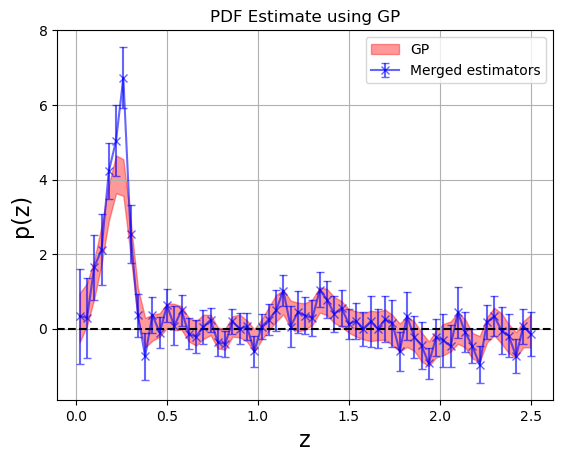

In [11]:
meas = inference.full_npz_tomo(
    path_dictionary=path_dictionary,
    scale_cuts=[1, 5],
    tracer='Merged',
    tomo_bin=3,
    verbose=True,
    rebin=1
)
zval = (zbins[1:] + zbins[:-1])/2  # we only want the middle values

dz = np.diff(zval)[0]
y = meas[0] / np.sum(meas[0] * dz)
y_err = meas[1] / np.sum(meas[0] * dz)

y_mean, y_std = sgp.gpfit(zval, meas)
plt.errorbar(zval, y, y_err, label='Merged estimators', alpha=0.6, capsize=3, color='blue', marker='x')
plt.fill_between(zval, y_mean - y_std, y_mean + y_std, alpha=0.4, label='GP', color='red')
plt.axhline(0, color='k', linestyle='--')
plt.grid(True)
plt.xlabel('z', fontsize=16)
plt.ylabel('p(z)', fontsize=16)
plt.legend()
plt.title('PDF Estimate using GP')
plt.show()

In [12]:
importlib.reload(inference)
nz = []
nz_err = []
for i in range(1, 24):
    print(f'Processing tomo bin {i}')
    meas = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        do_bias_correction=False,
        scale_cuts=[1, 5],
        tracer='Merged',
        tomo_bin=i,
        verbose=True,
    )
    nz.append(meas[0])
    nz_err.append(meas[1])
nz = np.array(nz)
nz_err = np.array(nz_err)

Processing tomo bin 1
Using fine redshift : [0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08
 1.12 1.16 1.2  1.24 1.28 1.32 1.36 1.4  1.44 1.48 1.52 1.56 1.6  1.64
 1.68 1.72 1.76 1.8  1.84 1.88 1.92 1.96 2.   2.04 2.08 2.12 2.16 2.2
 2.24 2.28 2.32 2.36 2.4  2.44 2.48 2.52]
Using merged method for tracer Merged and tomo bin 1.
Processing tomo bin 2
Using fine redshift : [0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.84 0.88 0.92 0.96 1.   1.04 1.08
 1.12 1.16 1.2  1.24 1.28 1.32 1.36 1.4  1.44 1.48 1.52 1.56 1.6  1.64
 1.68 1.72 1.76 1.8  1.84 1.88 1.92 1.96 2.   2.04 2.08 2.12 2.16 2.2
 2.24 2.28 2.32 2.36 2.4  2.44 2.48 2.52]
Using merged method for tracer Merged and tomo bin 2.
Processing tomo bin 3
Using fine redshift : [0.   0.04 0.08 0.12 0.16 0.2  0.24 0.28 0.32 0.36 0.4  0.44 0.48 0.52
 0.56 0.6  0.64 0.68 0.72 0.76 0.8  0.8

In [13]:
(zbins[1:] + zbins[:-1])/2

array([0.02, 0.06, 0.1 , 0.14, 0.18, 0.22, 0.26, 0.3 , 0.34, 0.38, 0.42,
       0.46, 0.5 , 0.54, 0.58, 0.62, 0.66, 0.7 , 0.74, 0.78, 0.82, 0.86,
       0.9 , 0.94, 0.98, 1.02, 1.06, 1.1 , 1.14, 1.18, 1.22, 1.26, 1.3 ,
       1.34, 1.38, 1.42, 1.46, 1.5 , 1.54, 1.58, 1.62, 1.66, 1.7 , 1.74,
       1.78, 1.82, 1.86, 1.9 , 1.94, 1.98, 2.02, 2.06, 2.1 , 2.14, 2.18,
       2.22, 2.26, 2.3 , 2.34, 2.38, 2.42, 2.46, 2.5 ])

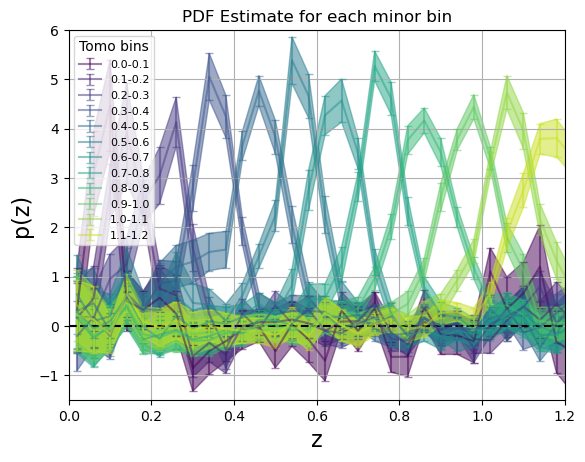

In [14]:
stds = []
viridis = plt.get_cmap('viridis')
tomo_bin = [0, 1.2]
zval = (zbins[1:] + zbins[:-1])/2
dz = 0.1
tomo_vals = np.arange(0, zval.max() + dz, dz)
haserr = True
plotted_indices = []

for i in range(nz.shape[0]):
    if tomo_vals[i] > tomo_bin[1]-dz/2 or tomo_vals[i] < tomo_bin[0]-dz/2:
        continue
    plotted_indices.append(i)

for num, i in enumerate(plotted_indices):
    integrated_nz = simpson(nz[i], zval)
    stds.append(np.std(nz[i]/integrated_nz))
    if haserr:
        plt.errorbar(
            zval, 
            nz[i], 
            nz_err[i], 
            label=f'{tomo_vals[i]:.1f}-{tomo_vals[i+1]:.1f}', 
            alpha=0.5,
            color=viridis(num/len(plotted_indices)), 
            capsize=3
        )
    
    plt.fill_between(
        zval, 
        (nz[i] - nz_err[i]), 
        (nz[i] + nz_err[i]), 
        alpha=0.5,
        color=viridis(num/len(plotted_indices)), 
        #label=f'{stds[i]:.2f}', 
    )
plt.xlim(0., 1.2)
plt.ylim(-1.5, 6)
plt.grid()
plt.xlabel('z', fontsize=16)
plt.ylabel('p(z)', fontsize=16)
plt.legend(loc='upper left', fontsize=8, title='Tomo bins')
plt.title('PDF Estimate for each minor bin')
plt.axhline(0, color='k', linestyle='--')

zeff = [0.09860381 0.19131671 0.32667667 0.43421602 0.54701895 0.66245985
 0.7883621  0.90576065 1.0202236  1.1460528  1.2602623  1.3818929
 1.5008993  1.6199856  1.7443753  1.8636682  1.9816954  2.1022532
 2.2237961  2.3453999  2.4660099  2.585058   2.7040384 ]


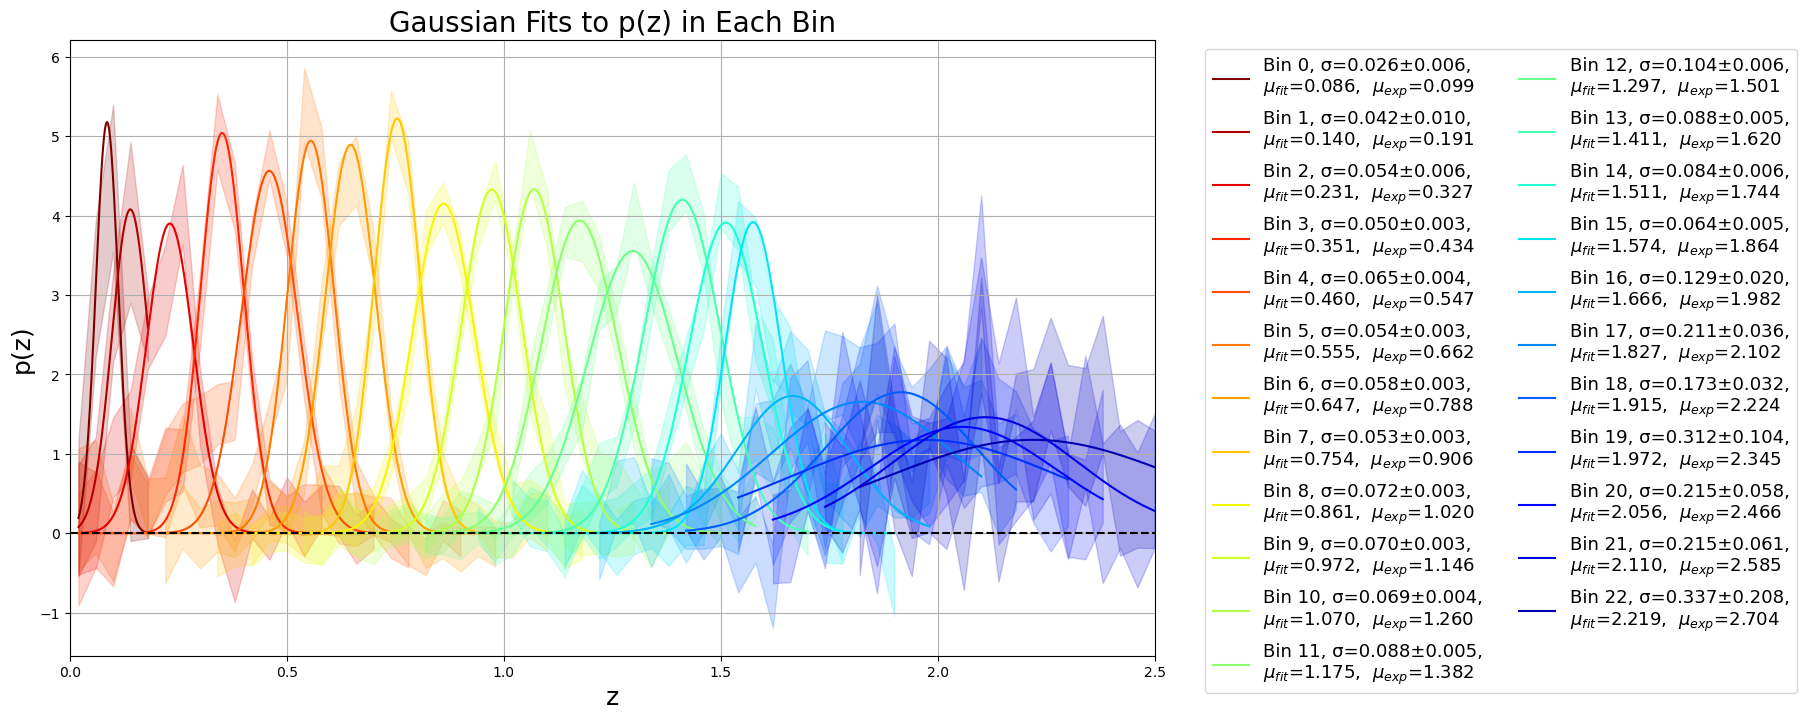

Bin 1: mean = 0.0858, std = 0.0256 ± 0.0060, meas_std = 5.6339
Bin 2: mean = 0.1395, std = 0.0424 ± 0.0096, meas_std = 2.3649
Bin 3: mean = 0.2306, std = 0.0544 ± 0.0061, meas_std = 1.4516
Bin 4: mean = 0.3510, std = 0.0499 ± 0.0034, meas_std = 1.4590
Bin 5: mean = 0.4598, std = 0.0647 ± 0.0041, meas_std = 1.4980
Bin 6: mean = 0.5554, std = 0.0543 ± 0.0032, meas_std = 1.3973
Bin 7: mean = 0.6469, std = 0.0584 ± 0.0034, meas_std = 1.4810
Bin 8: mean = 0.7543, std = 0.0534 ± 0.0027, meas_std = 1.8048
Bin 9: mean = 0.8614, std = 0.0720 ± 0.0033, meas_std = 1.1687
Bin 10: mean = 0.9722, std = 0.0698 ± 0.0035, meas_std = 1.0945
Bin 11: mean = 1.0699, std = 0.0688 ± 0.0037, meas_std = 0.9386
Bin 12: mean = 1.1749, std = 0.0883 ± 0.0047, meas_std = 0.8699
Bin 13: mean = 1.2972, std = 0.1044 ± 0.0060, meas_std = 0.9102
Bin 14: mean = 1.4112, std = 0.0884 ± 0.0050, meas_std = 1.0610
Bin 15: mean = 1.5115, std = 0.0841 ± 0.0057, meas_std = 1.1020
Bin 16: mean = 1.5744, std = 0.0638 ± 0.0055, mea

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import simpson
cmap = plt.get_cmap('jet_r')

# Gaussian model
def gaussian(z, A, mu, sigma):
    return A * np.exp(-0.5 * ((z - mu) / sigma)**2)

means = []
stds = []
meas_stds = []
stds_err = [] 

plt.figure(figsize=(14, 8))

hsc_redshifts = np.load('zeff/hsc_z_clustering_catalogs.npy')
zeff = np.array(
    [np.mean(hsc_redshifts[(i*0.12 < hsc_redshifts) & (hsc_redshifts <= (i+1)*0.12)]) for i in range(nz.shape[0])]
)
print(f'zeff = {zeff}')

for i in range(nz.shape[0]):
    if i == 0:
        mask_redshift = (zval >= 0) & (zval <= 0.2)
    elif i == 1:
        mask_redshift = (zval >= 0.) & (zval <= 0.2)
    else:
        mask_redshift = (zval >= (i-4)*0.1) & (zval <= (i+4)*0.1)
    mask = ~np.isnan(nz[i]) & mask_redshift # Mask NaN values and restrict to z range
    z = zval[mask]
    y = nz[i][mask]
    yerr = nz_err[i][mask]

    # Initial guess
    A0 = np.max(y)
    mu0 = np.sum(z * y) / np.sum(y)
    sigma0 = np.sqrt(np.sum(y * (z - mu0)**2) / np.sum(y))

    try:
        popt, pcov = curve_fit(
            gaussian, z, y, p0=[A0, mu0, sigma0], sigma=yerr, absolute_sigma=True
        )
        A_fit, mu_fit, sigma_fit = popt
        sigma_fit_err = np.sqrt(pcov[2, 2])  # <-- get std error

        # Store results
        means.append(mu_fit)
        stds.append(sigma_fit)
        stds_err.append(sigma_fit_err)  # <-- store std error

        zfit = np.linspace(z.min(), z.max(), 300)
        color = cmap(i / nz.shape[0])  # Use colormap for color cycling
        plt.plot(
            zfit, 
            gaussian(zfit, *popt), 
            label=(
                f'Bin {i}, σ={sigma_fit:.3f}±{sigma_fit_err:.3f},\n' 
                + r'$\mu_{fit}$' 
                + f'={mu_fit:.3f},  ' 
                + r'$\mu_{exp}$'
                + f'={zeff[i]:.3f}'
            ), 
            color=color
        )
        plt.fill_between(z, y - yerr, y + yerr, alpha=0.2, color=color)

    except RuntimeError:
        print(f"Fit failed for bin {i}")
        means.append(np.nan)
        stds.append(np.nan)
        stds_err.append(np.nan)
    meas_stds.append(np.std(nz[i] / simpson(nz[i], zval)))

plt.grid()
plt.xlabel('z', fontsize=18)
plt.ylabel('p(z)', fontsize=18)
plt.title('Gaussian Fits to p(z) in Each Bin', fontsize=20)
plt.axhline(0, color='k', linestyle='--')
plt.legend(ncols=2, fontsize=13, loc='upper right', bbox_to_anchor=(1.6, 1.0))
plt.xlim(0, 2.5)
plt.show()

# Final results
for i, (m, s, ms, s_err) in enumerate(zip(means, stds, meas_stds, stds_err)):
    print(f"Bin {i+1}: mean = {m:.4f}, std = {s:.4f} ± {s_err:.4f}, meas_std = {ms:.4f}")

Effective redshift for DESI from 0.0 to 0.1: 0.0764
Effective redshift for DESI from 0.1 to 0.2: 0.1548
Effective redshift for DESI from 0.2 to 0.30000000000000004: 0.2453
Effective redshift for DESI from 0.30000000000000004 to 0.4: 0.3555
Effective redshift for DESI from 0.4 to 0.5: 0.4567
Effective redshift for DESI from 0.5 to 0.6000000000000001: 0.5531
Effective redshift for DESI from 0.6000000000000001 to 0.7000000000000001: 0.6493
Effective redshift for DESI from 0.7000000000000001 to 0.8: 0.7522
Effective redshift for DESI from 0.8 to 0.9: 0.8502
Effective redshift for DESI from 0.9 to 1.0: 0.9474
Effective redshift for DESI from 1.0 to 1.1: 1.0493
Effective redshift for DESI from 1.1 to 1.2000000000000002: 1.1503
Effective redshift for DESI from 1.2000000000000002 to 1.3: 1.2485
Effective redshift for DESI from 1.3 to 1.4000000000000001: 1.3459
Effective redshift for DESI from 1.4000000000000001 to 1.5: 1.4504
Effective redshift for DESI from 1.5 to 1.6: 1.5456
Effective redshi

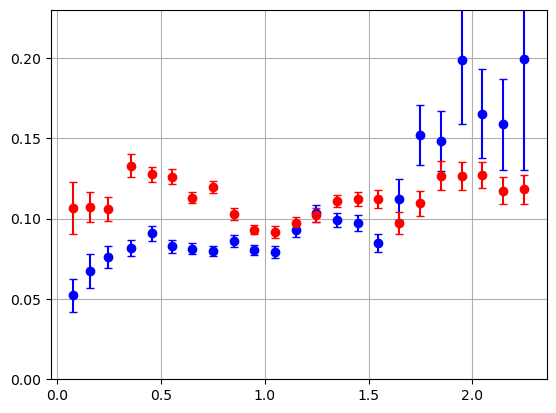

In [16]:
importlib.reload(inference)
importlib.reload(comb)
wpp = []
wpp_err = []
zeff = []
for i in range(1, len(stds)+1):
    ## now let's get the wpp measurements to get the full correction
    wpp_meas, wpp_err_meas, _ = inference.wpp(
            path=path_dictionary['HSC'],
            scale_cuts=[1, 5],
            bin_index=i,
        )
    wpp_err.append(wpp_err_meas)
    wpp.append(wpp_meas)
    zeff.append(cf.get_zeff(zlow=(i-1)*0.1, zhigh=i*0.1, type='HSC'))
print(f'zeff = {zeff}')
print(f'wpp = {wpp}')
print(f'wpp_err = {wpp_err}')
errs = comb.combine_error_bars_mult(wpp, wpp_err, stds, stds_err)
vals = np.sqrt(np.array(wpp)*np.array(stds))
#plt.plot(means, np.sqrt(np.array(wpp)*np.array(stds)), label='wpp')
plt.errorbar(zeff, vals, errs, label='correction', capsize=3, fmt='o', color='blue')
plt.errorbar(zeff, wpp, wpp_err, label='wpp', capsize=3, fmt='o', color='red')
plt.ylim(0, 0.23)
plt.grid()

In [ ]:
from scipy.optimize import curve_fit

def power_law(z, a, gamma):
    return a * (1 + z)**gamma

# Var(f) ≈ (df/da)^2 * Var(a) + (df/dγ)^2 * Var(γ) + 2*Cov(a,γ)*df/da*df/dγ
def power_law_error(z, a, gamma, pcov):
    da = (1 + z)**gamma
    dgamma = a * (1 + z)**gamma * np.log(1 + z)
    var = (
        da**2 * pcov[0, 0] +
        dgamma**2 * pcov[1, 1] +
        2 * da * dgamma * pcov[0, 1]
    )
    return np.sqrt(var)

nonnan_mask = ~np.isnan(np.array(vals))
zeff_arr = np.array(zeff)[nonnan_mask]
vals_arr = np.array(vals)[nonnan_mask]
errs_arr = np.array(errs)[nonnan_mask]

p0 = [np.mean(vals_arr), 1.0]

popt, pcov = curve_fit(
    power_law, zeff_arr, vals_arr, p0=p0, sigma=errs_arr, absolute_sigma=True
)
a_fit, gamma_fit = popt
a_err, gamma_err = np.sqrt(np.diag(pcov))

print(f"\nFitted power law:\n  a = {a_fit} ± {a_err}\n  gamma = {gamma_fit} ± {gamma_err}")

# Create fit curve and error band
z_plot = np.linspace(min(zeff_arr)-0.01, max(zeff_arr)+0.01, 300)
fit_vals = power_law(z_plot, a_fit, gamma_fit)

fit_errs = power_law_error(z_plot, a_fit, gamma_fit, pcov)

plt.figure(figsize=(5, 3))

dz = 1
plt.plot(z_plot, fit_vals/dz, 'r-', label=fr'Fit: $\propto(1+z)^{{{gamma_fit:.2f}±{gamma_err:.2f}}}$')
plt.fill_between(z_plot, (fit_vals - fit_errs)/dz, (fit_vals + fit_errs)/dz, color='red', alpha=0.3)#, label='Fit ±1σ')

plt.ylim(0, 0.2)
plt.xlim(0, 1.7)
plt.legend()
plt.ylabel(r'$\sqrt{w_{pp}\sigma}$', fontsize=14)
plt.errorbar(zeff, vals/dz, errs/dz, label='wpp', capsize=3, fmt='o', color='blue')
plt.xlabel(r'$z_{\rm eff}$', fontsize=14)
plt.title('Power-law Fit to ' + r'$\sqrt{w_{pp}\sigma}$', fontsize=16)
plt.grid()
plt.show()

# Tail removal plots

In [154]:
stem = 'v9_symexpr_20_excl'
path_dictionary = {
    'HSC' : ROOT / 'v12_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / 'v10' / f'autos_NGC',
    'DESI_SGC' : ROOT / 'v10' / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
}
assert all([p.exists() for p in path_dictionary.values()])
outdir = ROOT / f'merged_{stem}'
path_dictionary.update({
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
})

In [165]:
importlib.reload(inference)
importlib.reload(comb)
inference.merge_estimators(
    path_dictionary=path_dictionary, 
    outdir=outdir, 
    tomo_interest=[3],
)

Processing redshift bin 0 (Completion : 1.79%)
Processing redshift bin 5 (Completion : 10.71%)
Processing redshift bin 10 (Completion : 19.64%)
Processing redshift bin 15 (Completion : 28.57%)
Processing redshift bin 20 (Completion : 37.50%)
Processing redshift bin 25 (Completion : 46.43%)
Processing redshift bin 30 (Completion : 55.36%)
Processing redshift bin 35 (Completion : 64.29%)
Processing redshift bin 40 (Completion : 73.21%)
Processing redshift bin 45 (Completion : 82.14%)
Processing redshift bin 50 (Completion : 91.07%)
Processing redshift bin 55 (Completion : 100.00%)


zeff = [0.0347693  0.07759296 0.12665131 0.17575151 0.22482497 0.27404603
 0.32393083 0.37330081 0.42347698 0.47350585 0.52557593 0.57538912
 0.62527369 0.67527805 0.72542612 0.7758609  0.82548476 0.87483143
 0.92488506 0.9743975  1.02408659 1.07442255 1.12495753 1.1749018
 1.22475909 1.27483098 1.32495408 1.3747339  1.42491349 1.47396121
 1.52443496 1.57456234 1.62520736 1.6749617  1.72500914 1.77491857
 1.82501929 1.87496822 1.92492935 1.97466114 2.02475569 2.074603
 2.12482457 2.17456537 2.22471904 2.27458471 2.3243192  2.37479401
 2.42459292 2.47467053 2.52491472 2.57436009 2.62482698 2.67448626
 2.72458    2.77455367]
Using merged method for tracer Merged and tomo bin 1.
Using merged method for tracer Merged and tomo bin 2.
Using merged method for tracer Merged and tomo bin 3.
Using merged method for tracer Merged and tomo bin 4.
Tomo 1 :
0.47174669654688617
0.02979841049291654

Tomo 2 :
0.7636078953472815
0.6133393299388175

Tomo 3 :
1.0612799623147284
1.0191492332805756

Tomo 4 

(-1.2, 4.4)

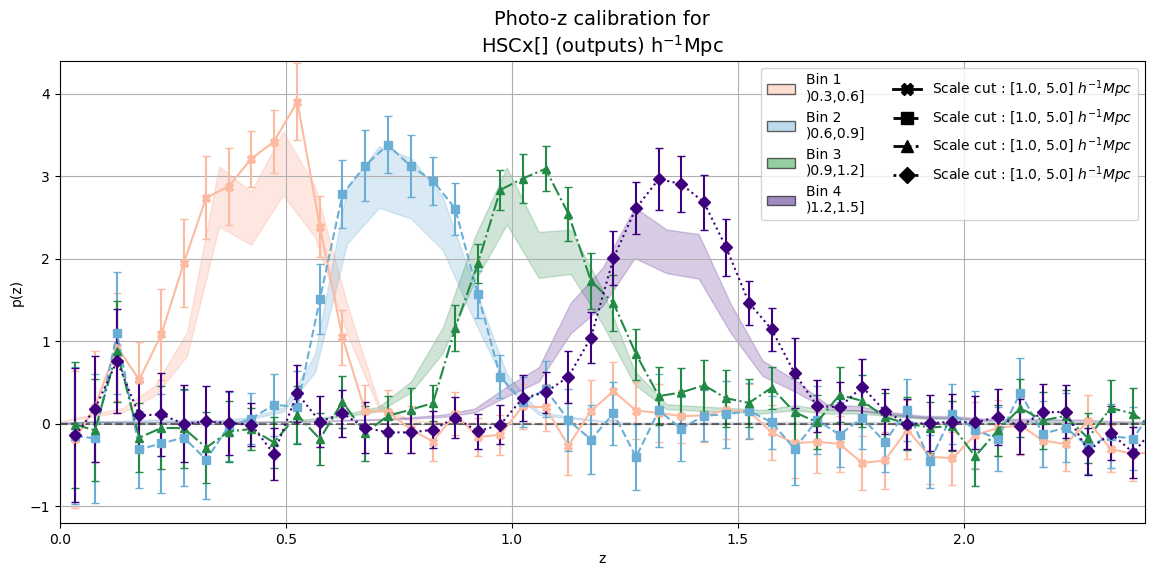

In [21]:
importlib.reload(inference)
ncurves = 0
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['X', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(14, 6))

scale_cut = [1, 5]  # scale cuts for the analysis

tomo_interest = [1,2,3,4]  # tomographic bins of interest
title = 'Photo-z calibration for\nHSCx['
zbins = inference._get_fine_redshift_bins(fr=cf.CorrFileReader(path_dictionary["DESI_NGC"]))
redshifts = np.load('zeff/desi_z_clustering_catalogs.npy')
zeff = np.array(
    [np.mean(redshifts[(zbins[i] < redshifts) & (redshifts <= zbins[i+1])]) for i in range(len(zbins)-1)]
)
print(f'zeff = {zeff}')

nz = []
nz_err = []
for tomo in tomo_interest:
    tomo_nz, tomo_nz_err = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        scale_cuts=scale_cut,
        tracer="Merged",
        tomo_bin=tomo,
        rebin=1,
        )
    nonnanz = ~np.isnan(tomo_nz)
    tomo_nz = tomo_nz[nonnanz]
    tomo_nz_err = tomo_nz_err[nonnanz]
    zval = zeff[nonnanz]
    nz_int = simpson(tomo_nz, x=zval)
    nz.append(tomo_nz/nz_int)
    nz_err.append(tomo_nz_err/nz_int)
    tomo_index = tomo-1 if len(tomo_interest) > 1 else 0
    ax.errorbar(
        x=zval, 
        y=nz[tomo_index],
        yerr=nz_err[tomo_index],#/normalization, 
        capsize=3,
        marker=markers[tomo_index], 
        linestyle=linestyles[tomo_index],
        markersize=6,   
        alpha=1,
        color=colormaps[tomo_index]((tomo)/4),
        )
    
mids = tomo_bin_dnnz[:, 0]

dnnz_list = []
mu_list = []
cov_list = []

ids_to_skip = []

for dnnz_idx in range(0, 4):
    ncurves += 1

    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx+1], mids)
    dnnz_list.append(np.percentile(dnnz, 50, axis=0))
    mu_list.append(mu)
    cov_list.append(cov)

    ax.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=colormaps[dnnz_idx]((dnnz_idx+2)/5), 
        alpha=0.2
        )
        
title+=f'] ({ROOT.name}) ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('z')
ax.set_ylabel('p(z)')

legend_elements = []

for bin_id in tomo_interest:
    patch = Patch(
        facecolor=colormaps[bin_id-1](bin_id/len(bins_hsc)),
        alpha=0.6,
        edgecolor='black',
        label=f'Bin {bin_id}\n){bins_hsc[bin_id-1]:.1f},{bins_hsc[bin_id]:.1f}]',
    )
    legend_elements.append(patch)

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=f'Scale cut : [{scale_cut[0]:.1f}, {scale_cut[1]:.1f}] ' + r'$h^{-1}Mpc$', 
        linewidth=2
    )
    legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=2, 
    fontsize=10,
)

for i in range(len(nz)):
    print(f'Tomo {i+1} :')
    assert len(nz[i]) == len(zval), f'Length mismatch for tomo {i+1}'
    print(f'{simpson(np.multiply(mids, dnnz_list[i]), x=mids)}')
    print(f'{simpson(np.multiply(nz[i], zval), x=zval)}\n')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)
ax.grid()
ax.set_title(title, fontsize=14)
ax.set_xlim(0, 2.4)
ax.set_ylim(-1.2, 4.4)

## Gaussian Process Models

In [22]:
stem = 'v10'
outdir = ROOT / f'merged_{stem}'
path_dictionary = {
    'HSC' : ROOT / 'v11_correction' / f'autos_HSC', # with no wpp correction, is unused
    'DESI_NGC' : ROOT / stem / f'autos_NGC',
    'DESI_SGC' : ROOT / stem / f'autos_SGC',
    'DESIxHSC' : ROOT / stem / f'cross',
    'MergedxMerged' : outdir,
    'MergedxHSC' : outdir,
}

zeff = [0.0347693  0.07759296 0.12665131 0.17575151 0.22482497 0.27404603
 0.32393083 0.37330081 0.42347698 0.47350585 0.52557593 0.57538912
 0.62527369 0.67527805 0.72542612 0.7758609  0.82548476 0.87483143
 0.92488506 0.9743975  1.02408659 1.07442255 1.12495753 1.1749018
 1.22475909 1.27483098 1.32495408 1.3747339  1.42491349 1.47396121
 1.52443496 1.57456234 1.62520736 1.6749617  1.72500914 1.77491857
 1.82501929 1.87496822 1.92492935 1.97466114 2.02475569 2.074603
 2.12482457 2.17456537 2.22471904 2.27458471 2.3243192  2.37479401
 2.42459292 2.47467053 2.52491472 2.57436009 2.62482698 2.67448626
 2.72458    2.77455367]
Using merged method for tracer Merged and tomo bin 1.
GP kernel: 0.891**2 * Matern(length_scale=0.0991, nu=1.5)
Using merged method for tracer Merged and tomo bin 2.
GP kernel: 0.84**2 * Matern(length_scale=0.1, nu=1.5)
Using merged method for tracer Merged and tomo bin 3.
GP kernel: 0.641**2 * Matern(length_scale=0.1, nu=1.5)
Using merged method for tracer Merged an

(-1.2, 4.5)

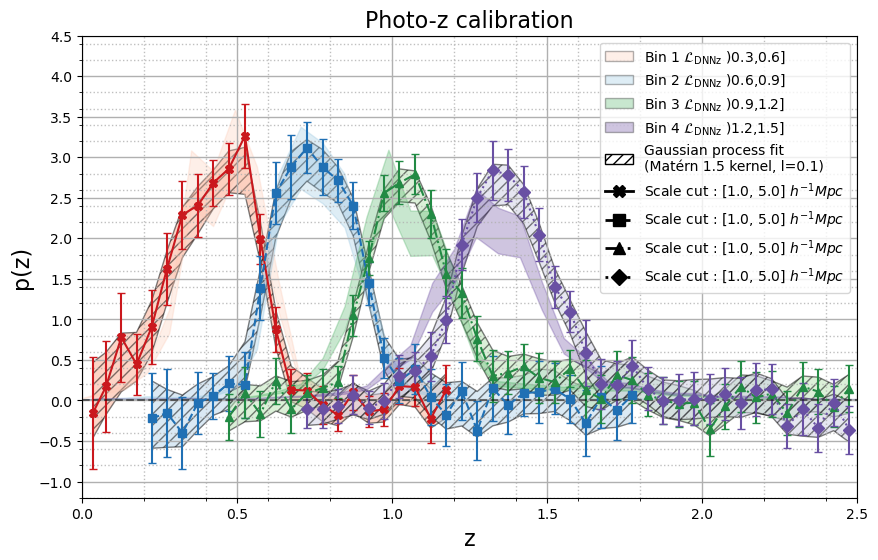

In [23]:
importlib.reload(inference)
importlib.reload(comb)
importlib.reload(sgp)
ncurves = 0
tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELGnotqso' : 'ELG',
    'QSO' : 'QSO',
}

bins_hsc = np.arange(0.3, 1.8, 0.3)

colormaps = [plt.get_cmap(c) for c in ['Reds', 'Blues', 'Greens', 'Purples']]
markers = ['X', 's', '^', 'D']
linestyles = ['-', '--', '-.', ':']
tomo_bin_dnnz = np.loadtxt('hsc_pz/data/tomographic_binning_dnnz.dat')

fig, ax = plt.subplots(figsize=(10, 6))

scale_cut = [1, 5]

tomo_interest = [1,2,3,4]  # tomographic bins of interest
title = 'Photo-z calibration'
zbins = inference._get_fine_redshift_bins(fr=cf.CorrFileReader(path_dictionary["DESI_NGC"]))
redshifts = np.load('zeff/desi_z_clustering_catalogs.npy')
zeff = np.array(
    [np.mean(redshifts[(zbins[i] < redshifts) & (redshifts <= zbins[i+1])]) for i in range(len(zbins)-1)]
)
print(f'zeff = {zeff}')

nz = []
nz_err = []
for tomo_index, tomo in enumerate(tomo_interest):
    tomo_nz, tomo_nz_err = inference.full_npz_tomo(
        path_dictionary=path_dictionary,
        scale_cuts=scale_cut,
        do_bias_correction=True,
        tracer="Merged",
        tomo_bin=tomo,
        rebin=1,
        )
    if tomo == 1:
        zmask = (zeff >=0) & (zeff <= 1.2)
    if tomo > 1:
        zmask = (zeff >=0.2)
        if tomo == 2:
            zmask &= (zeff <= 1.8)
        if tomo == 3:
            zmask = (zeff >=0.45) & (zeff <= 2.5)
        if tomo == 4:
            zmask = (zeff >=0.7) & (zeff <= 2.5)


    nonnanz = ~np.isnan(tomo_nz)
    mask_tomo = nonnanz & zmask
    tomo_nz = tomo_nz[mask_tomo]
    tomo_nz_err = tomo_nz_err[mask_tomo]
    zval = zeff[mask_tomo]
    nz_int = simpson(tomo_nz, x=zval)
    nz.append(tomo_nz/nz_int)
    nz_err.append(tomo_nz_err/nz_int)

    dz = np.diff(zval)[0]
    y_mean, y_std = sgp.gpfit(zval, (tomo_nz/nz_int, tomo_nz_err/nz_int))

    ax.fill_between(
        zval,
        y_mean - y_std,
        y_mean + y_std,
        alpha=0.5,
        color=colormaps[tomo-1](0.3),
        edgecolor='black',
        label=f'{tracer_trad[tracers[tomo-1]]} (GP)',
        hatch='///'
    )

    ax.errorbar(
        x=zval, 
        y=nz[tomo-1 if len(tomo_interest) > 1 else tomo_index],
        yerr=nz_err[tomo-1 if len(tomo_interest) > 1 else tomo_index],#/normalization, 
        capsize=3,
        marker=markers[tomo-1], 
        linestyle=linestyles[tomo-1],
        markersize=6,   
        alpha=1,
        color=colormaps[tomo-1](3/4),
        )
        
    #title+= f'x{tracer_trad[tracers[tomo-1]]}'

mids = tomo_bin_dnnz[:, 0]
mask_mids = mids < 2.725

dnnz_list = []
mu_list = []
cov_list = []

ids_to_skip = []

for dnnz_idx in range(1, 5):
    if dnnz_idx not in tomo_interest:
        continue
    ncurves += 1

    dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, dnnz_idx], mids)
    dnnz_list.append(np.percentile(dnnz, 50, axis=0))
    mu_list.append(mu)
    cov_list.append(cov)

    if len(tomo_interest) == 1:
        col = 'gray'
    else:
        col = colormaps[dnnz_idx-1](dnnz_idx/len(bins_hsc))

    ax.fill_between(
        mids, 
        np.percentile(dnnz, 16, axis=0), 
        np.percentile(dnnz, 84, axis=0), 
        color=col, 
        alpha=0.3
        )
        
#title+=f'] ' +r'$\rm{h}^{-1}\rm{Mpc}$'
ax.set_xlabel('z', fontsize=16)
ax.set_ylabel('p(z)', fontsize=16)

legend_elements = []

for bin_id in tomo_interest:
    if len(tomo_interest) == 1:
        col = 'gray'
    else:
        col = colormaps[bin_id-1](bin_id/len(bins_hsc))
    patch = Patch(
        facecolor=col,
        alpha=0.3,
        edgecolor='black',
        label=f'Bin {bin_id} '
        + r'$\mathcal{L}_{\mathrm{DNNz}}$' 
        + f' ){bins_hsc[bin_id-1]:.1f},{bins_hsc[bin_id]:.1f}]',
    )
    legend_elements.append(patch)
legend_elements.append(Patch(
        facecolor='white',
        edgecolor='black',
        label='Gaussian process fit\n(Matérn 1.5 kernel, l=0.1)',
        hatch='///',
    ))

for i, (marker, linestyle, tracer) in enumerate(zip(markers, linestyles, tracers)):
    if i+1 not in tomo_interest:
        continue
    element = Line2D(
        [0], 
        [0], 
        color='black', 
        marker=marker, 
        linestyle=linestyle, 
        markersize=8, 
        label=f'Scale cut : [{scale_cut[0]:.1f}, {scale_cut[1]:.1f}] ' + r'$h^{-1}Mpc$', 
        linewidth=2
    )
    legend_elements.append(element)

ax.legend(
    handles=legend_elements, 
    loc='upper right', 
    ncol=1 if len(tomo_interest) == 1 else 1, 
    fontsize=12 if len(tomo_interest) == 1 else 10,
)

#for i in range(len(nz)):
#    print(f'Tomo {i+1} :')
#    assert len(nz[i]) == len(zval), f'Length mismatch for tomo {i+1}'
#    print(f'{simpson(np.multiply(mids, dnnz_list[i]), x=mids)}')
#    print(f'{simpson(np.multiply(nz[i], zval), x=zval)}\n')

ax.axhline(0, color='black', linestyle='--', alpha=0.5)

# X-axis: major ticks every 0.5, minor every 0.2
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.xaxis.set_minor_locator(MultipleLocator(0.2))

# Y-axis: major ticks every 0.5, minor every 0.2
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.2))

# Grid styling
ax.grid(which='major', linestyle='-', linewidth=1)
ax.grid(which='minor', linestyle=':', linewidth=1, alpha=0.8)

ax.set_title(title, fontsize=16)
ax.set_xlim(0., 2.5)
ax.set_ylim(-1.2, 4.5)

Magnification bias corrections :

$ w_{sp}(z_i) = n_p(z_i) b_p(z_i) b_s(z_i) w_{\mathrm{DM}}(z_i) + 
b_s(z_i) \alpha_p(z_i) \sum_{j>i} \left[ D_{ij} n_p(z_j) \right] + 
b_p(z_i) \alpha_s(z_i) \sum_{j>i} \left[ D_{ij} n_p(z_i) \right] $  

$ \frac{w_{sp}(z_i)}{\Delta z\sqrt{w_{pp}(z_i)w_{ss}(z_i)}} = n_p(z_i) + 
\frac{\alpha_p(z_i)}{b_p(z_i)} \sum_{j>i} \left[ D_{ij}^n n_p(z_j) \right] + 
\frac{\alpha_s(z_i)}{b_s(z_i)} \sum_{j>i} \left[ D_{ij}^n n_p(z_i) \right] $  

$ D_{ij}^n = \frac{D_{ij}}{w_{\mathrm{DM}}(z_i)} $  

$ D_{ij} = \frac{3 H_0^2 \Omega_m}{c^2} w_{\mathrm{DM}}(z_i)
\frac{\chi(z_j)\left[ \chi(z_j) - \chi(z_i) \right]}{a(z_i) \chi(z_j)} \Delta \chi_j $  

### Gaussian Mixture